In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

In [ ]:
# Bulk

In [2]:
pretrain_bulk = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/bulk/pretraining_bulk_RAW.h5ad")

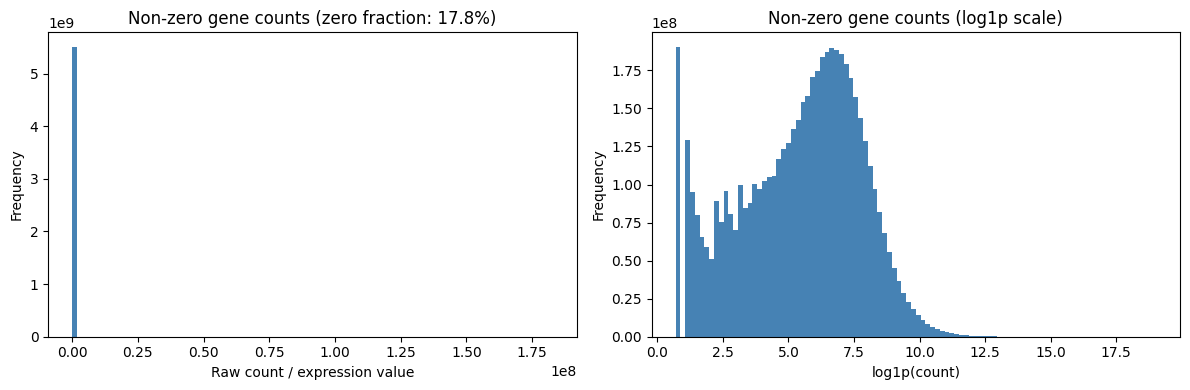

Sparsity: 17.8%
Non-zero value stats: min=1.00, median=313.00, max=182754896.00
Fraction that are exactly 1: 3.5%


In [3]:
# Extract non-zero values from sparse matrix
if sparse.issparse(pretrain_bulk.X):
    vals = pretrain_bulk.X.data  # only non-zero entries
else:
    vals = pretrain_bulk.X[pretrain_bulk.X > 0].ravel()

zero_frac = 1 - (len(vals) / (pretrain_bulk.n_obs * pretrain_bulk.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

# Log scale on x-axis — more informative for bulk TPM
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")


In [3]:
pretrain_bulk.X.mean(axis = 1).mean()

1428.2859

In [4]:
pretrain_bulk.X.getnnz(axis=1).mean()

9836.628308928572

[10720 11289 11217 11148 11335 11371 11396 11412 11530 11197]
mean: 9836.628308928572
median: 10689.0
min: 200
max: 11961


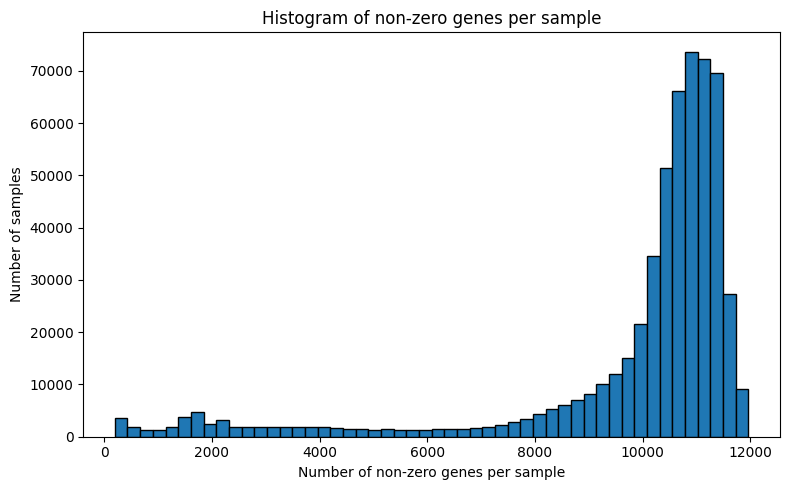

In [6]:
X = pretrain_bulk.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [ ]:
## Bulk - GTEx

In [7]:
pretrain_bulk_gtex = pretrain_bulk.copy()[pretrain_bulk.obs["dataset"] == "GTEx"]

In [8]:
pretrain_bulk_gtex.X.mean(axis = 1).mean()

3736.3965

In [9]:
pretrain_bulk_gtex.X.getnnz(axis=1).mean()

11342.134088134088

[10720 11289 11217 11148 11335 11371 11396 11412 11530 11197]
mean: 11342.134088134088
median: 11376.0
min: 10083
max: 11919


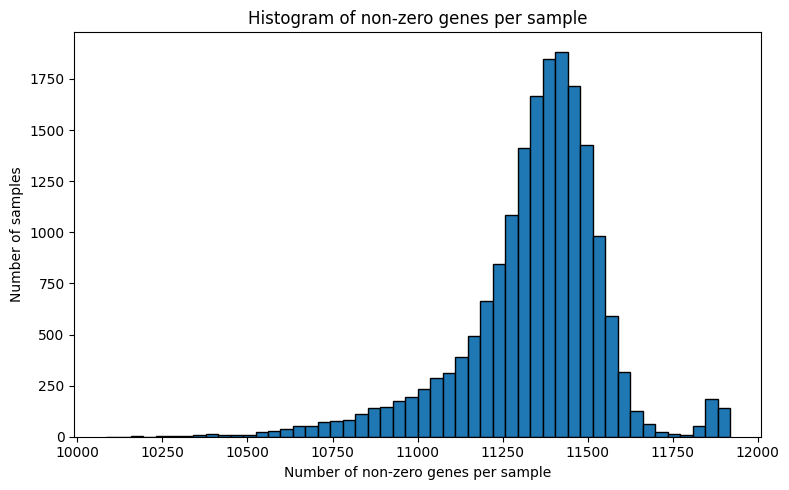

In [11]:
X = pretrain_bulk_gtex.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [12]:
## Bulk - ARCHS4

In [13]:
pretrain_bulk_archs4 = pretrain_bulk.copy()[pretrain_bulk.obs["dataset"] == "ARCHS4"]

In [14]:
pretrain_bulk_archs4.X.mean(axis = 1).mean()

1351.554

In [15]:
pretrain_bulk_archs4.X.getnnz(axis=1).mean()

9786.578301493408

[10192 10225 10287 10230 10220  3023  3429  3484  2853  2984]
mean: 9786.578301493408
median: 10658.0
min: 200
max: 11961


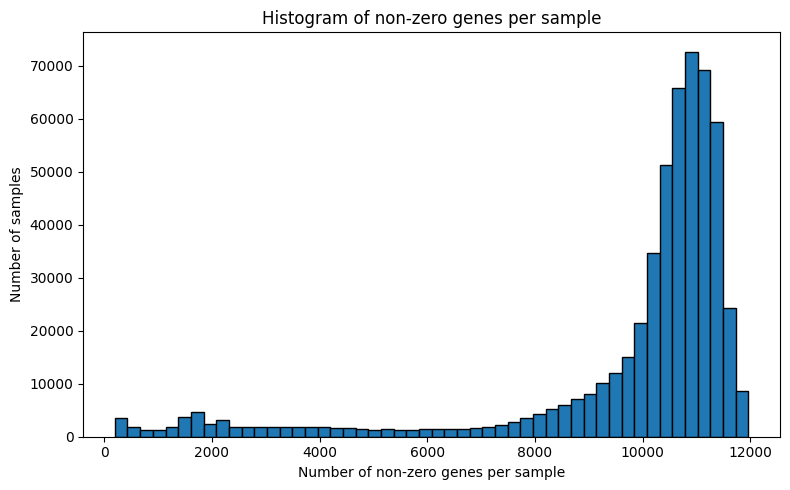

In [17]:
X = pretrain_bulk_archs4.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [18]:
# SC

In [4]:
pretrain_sc = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/sc/pretraining_sc_RAW.h5ad")

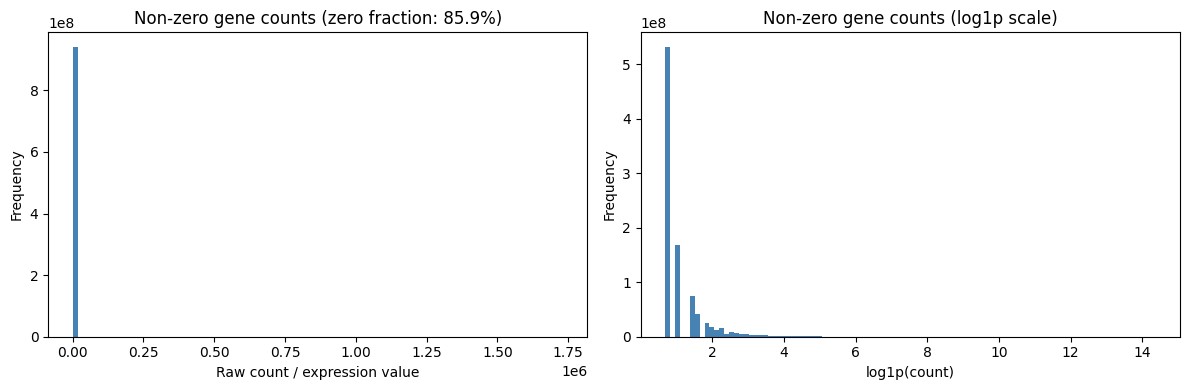

Sparsity: 85.9%
Non-zero value stats: min=1.00, median=1.00, max=1730805.00
Fraction that are exactly 1: 56.5%


In [5]:
# Extract non-zero values from sparse matrix
if sparse.issparse(pretrain_sc.X):
    vals = pretrain_sc.X.data  # only non-zero entries
else:
    vals = pretrain_sc.X[pretrain_.X > 0].ravel()

zero_frac = 1 - (len(vals) / (pretrain_sc.n_obs * pretrain_sc.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

# Log scale on x-axis — more informative for sc TPM
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [20]:
pretrain_sc.X.mean(axis = 1).mean()

0.6804685

In [21]:
pretrain_sc.X.getnnz(axis=1).mean()

1681.4283821428571

[1242  435  539  537 1153 1952 1087 1492 1628 1428]
mean: 1681.4283821428571
median: 1346.0
min: 200
max: 10850


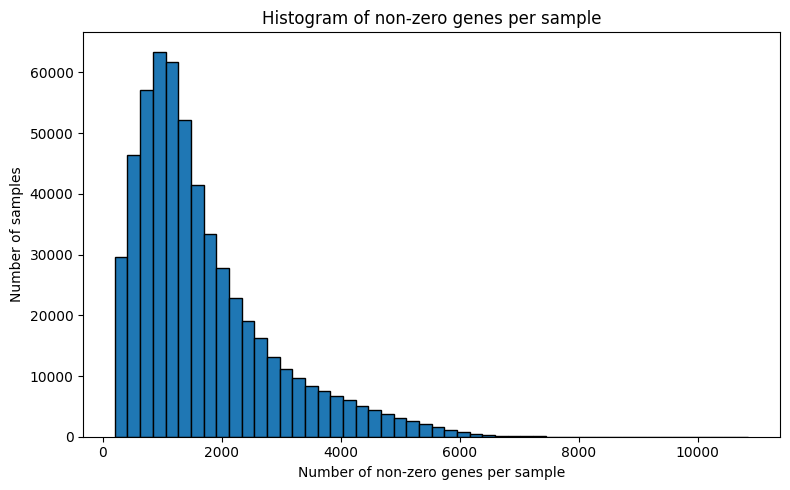

In [23]:
X = pretrain_sc.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [24]:
# Pseudo Bulk

In [2]:
pseudo_bulk = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/pseudo_bulk/pseudo_bulk_RAW.h5ad")

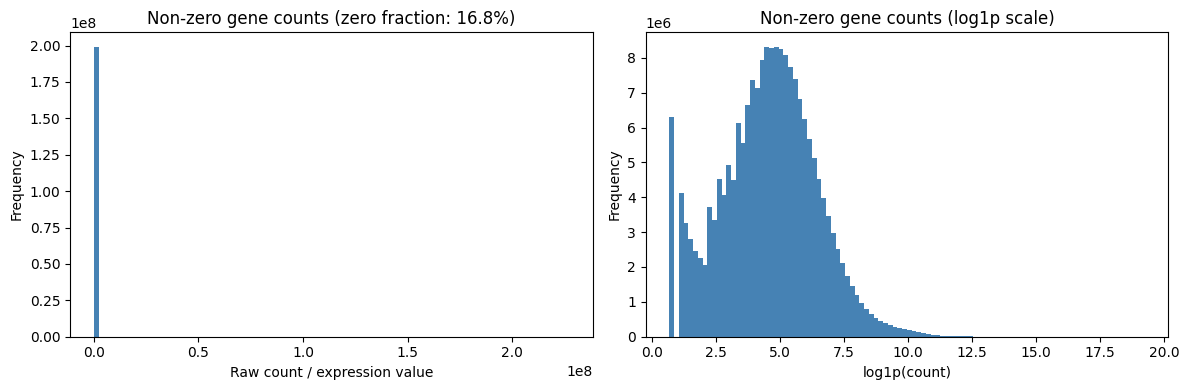

Sparsity: 16.8%
Non-zero value stats: min=1.00, median=102.00, max=226945472.00
Fraction that are exactly 1: 3.2%


In [3]:
# Extract non-zero values from sparse matrix
if sparse.issparse(pseudo_bulk.X):
    vals = pseudo_bulk.X.data  # only non-zero entries
else:
    vals = pretrain_pseudo_bulk.X[pseudo_bulk.X > 0].ravel()

zero_frac = 1 - (len(vals) / (pseudo_bulk.n_obs * pseudo_bulk.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

# Log scale on x-axis — more informative for pseudo bulk TPM
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")


In [26]:
pseudo_bulk.X.mean(axis = 1).mean()

655.86115

In [27]:
pseudo_bulk.X.getnnz(axis=1).mean()

9957.69205

[10858 10974  9663 11017 10578  9775 10278  9588  8783 10911]
mean: 9957.69205
median: 10216.0
min: 289
max: 11930


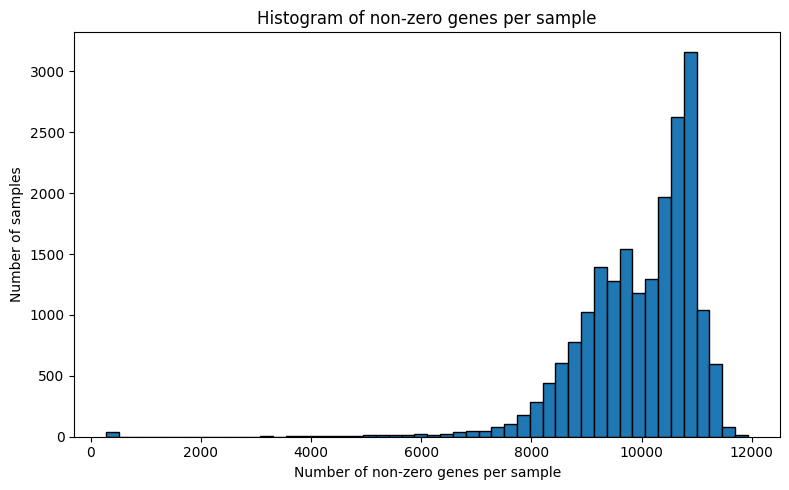

In [30]:
X = pseudo_bulk.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()